# Messages per Newsgroup (date-filtered IA)

Same as `messages_per_group.ipynb` but using IA data filtered to the NWA date span.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2

In [2]:
def load_group_counts(path):
    df = pd.read_csv(path)
    df = df[df.newsgroup != "Total"]
    df["newsgroup"] = df["newsgroup"].str.replace(".mbox", "", regex=False)
    return df.sort_values("message_count", ascending=False)


df_ia = load_group_counts("../data/messages_per_group_ia_date_filtered.csv")
df_nwa = load_group_counts("../data/messages_per_group_nwa.csv")
df_ia.head(10)

,newsgroup,message_count
28,no.general,76313
65,no.pc,31246
92,no.marked.data,28736
217,no.religion,23892
222,no.musikk,23014
236,no.test,20877
167,no.marked,19799
170,no.www,18707
220,no.mac,17764
250,no.amiga,17117


In [3]:
print(
    f"IA (date-filtered) — groups: {len(df_ia)}, total messages: {df_ia['message_count'].sum():,}"
)
print(
    f"NWA                — groups: {len(df_nwa)}, total messages: {df_nwa['message_count'].sum():,}"
)

shared = set(df_ia["newsgroup"]) & set(df_nwa["newsgroup"])
print(f"\nGroups in both: {len(shared)}")
print(f"IA only:        {len(set(df_ia['newsgroup']) - shared)}")
print(f"NWA only:       {len(set(df_nwa['newsgroup']) - shared)}")

IA (date-filtered) — groups: 280, total messages: 575,768
NWA                — groups: 155, total messages: 613,626

Groups in both: 132
IA only:        148
NWA only:       23


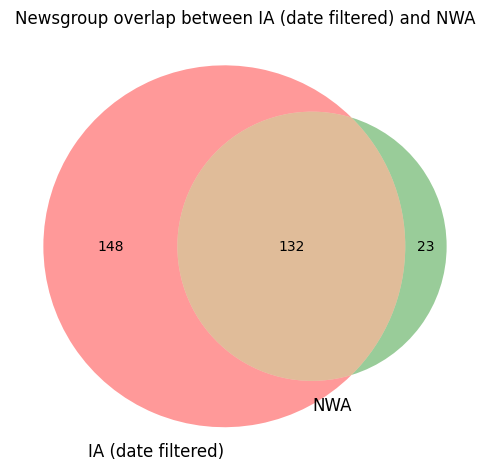

In [4]:
ia_groups = set(df_ia["newsgroup"])
nwa_groups = set(df_nwa["newsgroup"])

fig, ax = plt.subplots(figsize=(5, 5))
venn2([ia_groups, nwa_groups], set_labels=("IA (date filtered)", "NWA"), ax=ax)
ax.set_title("Newsgroup overlap between IA (date filtered) and NWA")
plt.tight_layout()
plt.show()

# Top 20 newsgroups

## Compare the most frequent newsgroups from the two sources

In [5]:
merged = df_ia.merge(df_nwa, on="newsgroup", suffixes=("_ia", "_nwa"))

merged["pct_ia"] = merged["message_count_ia"] / df_ia["message_count"].sum() * 100
merged["pct_nwa"] = merged["message_count_nwa"] / df_nwa["message_count"].sum() * 100

result = (
    merged[["newsgroup", "pct_ia", "pct_nwa"]]
    .sort_values("pct_ia", ascending=False)
    .reset_index(drop=True)
)
result["pct_ia"] = result["pct_ia"].map("{:.2f}%".format)
result["pct_nwa"] = result["pct_nwa"].map("{:.2f}%".format)

result.head(20)

,newsgroup,pct_ia,pct_nwa
0,no.general,13.25%,12.54%
1,no.pc,5.43%,4.20%
2,no.marked.data,4.99%,3.70%
3,no.religion,4.15%,3.33%
4,no.musikk,4.00%,4.49%
5,no.test,3.63%,0.56%
6,no.marked,3.44%,4.39%
7,no.www,3.25%,0.56%
8,no.mac,3.09%,3.61%
9,no.amiga,2.97%,0.53%


In [6]:
result_nwa = (
    merged[["newsgroup", "pct_ia", "pct_nwa"]]
    .sort_values("pct_nwa", ascending=False)
    .reset_index(drop=True)
)
result_nwa["pct_ia"] = result_nwa["pct_ia"].map("{:.2f}%".format)
result_nwa["pct_nwa"] = result_nwa["pct_nwa"].map("{:.2f}%".format)

result_nwa.head(20)

,newsgroup,pct_ia,pct_nwa
0,no.general,13.25%,12.54%
1,no.alt.motorsykler,0.00%,6.31%
2,no.alt.frustrasjoner,0.01%,4.58%
3,no.musikk,4.00%,4.49%
4,no.marked,3.44%,4.39%
5,no.pc,5.43%,4.20%
6,no.marked.data,4.99%,3.70%
7,no.mac,3.09%,3.61%
8,no.religion,4.15%,3.33%
9,no.alt.flame,2.81%,3.25%


In [7]:
def plot_top_vs_rest(df, title):
    top_20_sum = df.head(20)["message_count"].sum()
    rest_sum = df.iloc[20:]["message_count"].sum()
    rest_label = f"Rest ({len(df) - 20})"
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.bar(["Top 20", rest_label], [top_20_sum, rest_sum])
    for i, v in enumerate([top_20_sum, rest_sum]):
        ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Total Messages")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_distribution(df, title):
    bin_size = 5000
    max_count = int(np.ceil(df["message_count"].max() / bin_size) * bin_size)
    bins = np.arange(0, max_count + bin_size, bin_size)
    counts, bin_edges = np.histogram(df["message_count"], bins=bins)
    non_empty = np.where(counts > 0)[0]
    labels = [
        f"{int(bin_edges[i]):,}\u2013{int(bin_edges[i + 1]):,}".replace(",", " ")
        for i in non_empty
    ]
    counts = counts[non_empty]
    gap_width = 0.9
    x_positions = [0.0]
    for i in range(1, len(non_empty)):
        step = 1.0
        if non_empty[i] - non_empty[i - 1] > 1:
            step += gap_width
        x_positions.append(x_positions[-1] + step)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x_positions, counts, width=0.8)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    for x, c in zip(x_positions, counts):
        ax.text(x, c, str(c), ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("Message Count Range")
    ax.set_ylabel("Number of Newsgroups")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

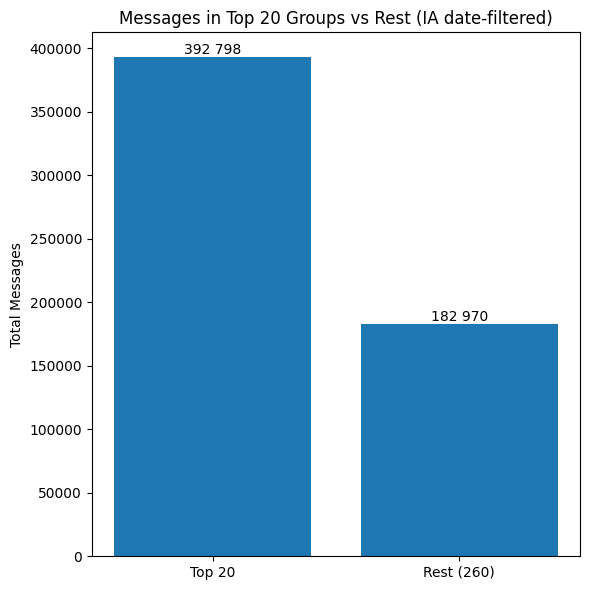

In [8]:
plot_top_vs_rest(df_ia, "Messages in Top 20 Groups vs Rest (IA date-filtered)")

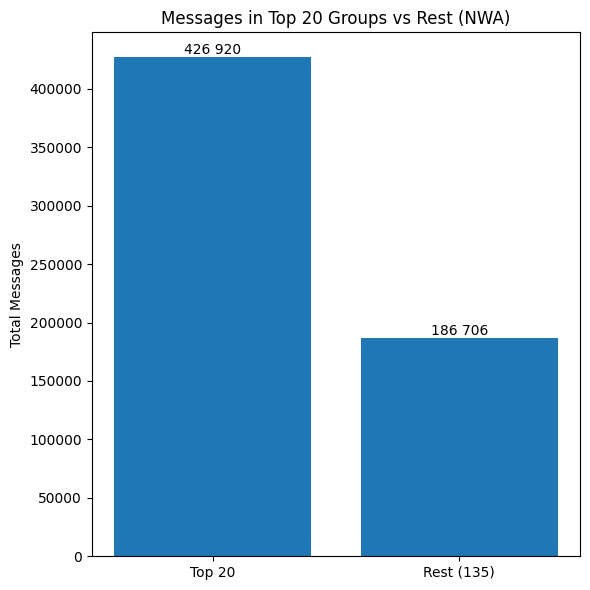

In [9]:
plot_top_vs_rest(df_nwa, "Messages in Top 20 Groups vs Rest (NWA)")

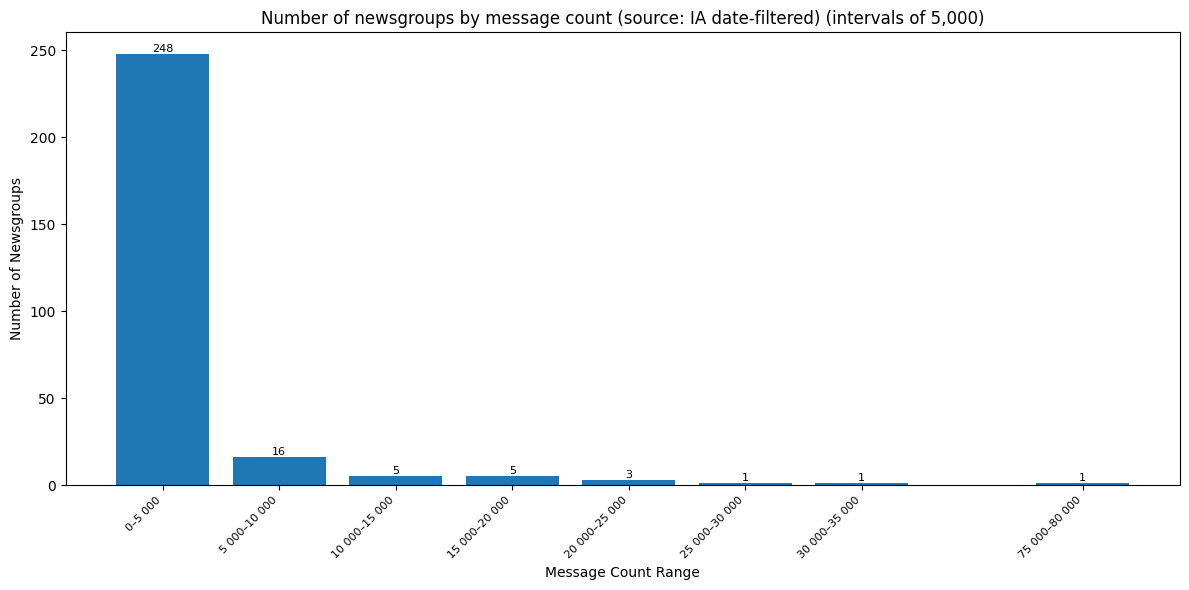

In [10]:
plot_distribution(
    df_ia,
    "Number of newsgroups by message count (source: IA date-filtered) (intervals of 5,000)",
)

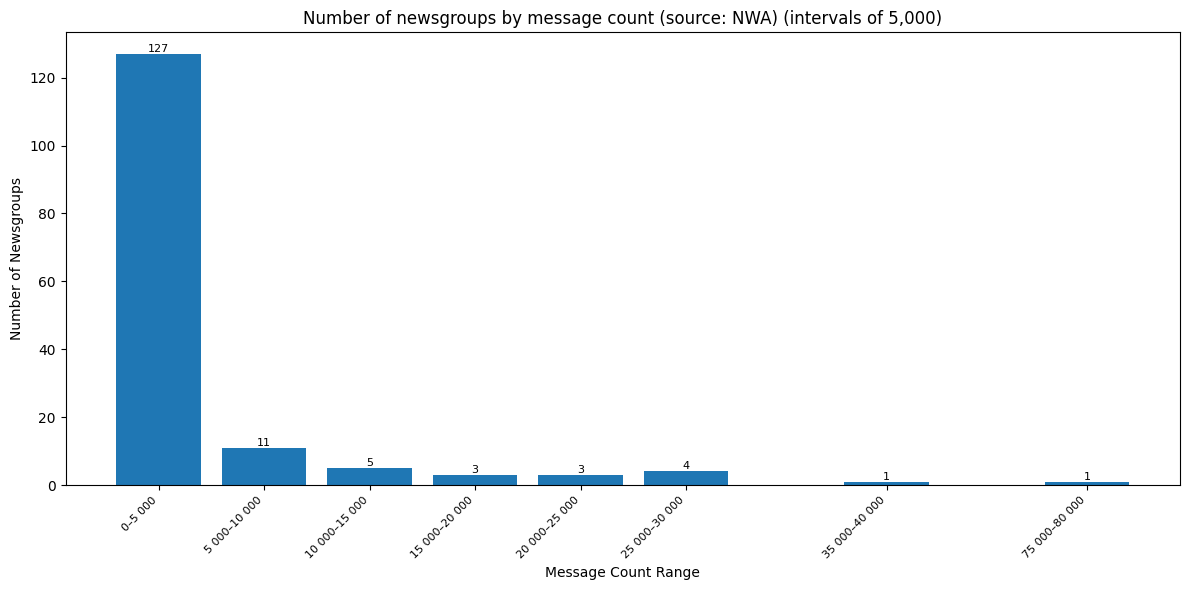

In [11]:
plot_distribution(
    df_nwa,
    "Number of newsgroups by message count (source: NWA) (intervals of 5,000)",
)